# Proyecto Grupal - Inteligencia de Negocios
## Parte 2: Visualización de Datos en Python

**Empresa:** Botica Los Andes  
**Objetivo:** Generar visualizaciones analíticas (evolución temporal, Pareto de categorías y mapa de calor) utilizando los datos procesados del Datamart para respaldar la toma de decisiones gerenciales.

### 1. Configuración del Entorno y Carga de Datos
En esta sección, importamos las librerías necesarias y cargamos los datos previamente limpiados (ETL) desde la carpeta `data/processed/` utilizando rutas relativas para mantener la compatibilidad con el repositorio de GitHub.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path.cwd().parent

# 1. Definir rutas relativas basadas en la estructura del repositorio
ruta_datos = BASE_DIR / "data" / "processed"

# 2. Cargar las tablas procesadas
print("Cargando datos procesados desde /data/processed/...")
fact_ventas = pd.read_csv(ruta_datos / 'Fact_Ventas.csv', sep=';')
dim_tiempo = pd.read_csv(ruta_datos / 'Dim_Tiempo.csv', sep=';')
dim_producto = pd.read_csv(ruta_datos / 'Dim_Producto.csv', sep=';')

# 3. Integrar modelo dimensional (Merge)
print("Integrando modelo dimensional...")
df = fact_ventas.merge(dim_tiempo, on="fecha", how="left")
df = df.merge(dim_producto, on="id_producto", how="left")

# 4. Asegurar formato de fecha para análisis temporal
df["fecha"] = pd.to_datetime(df["fecha"])

print(f"Datos listos para análisis. Total de filas: {len(df)}")
display(df.head(3))

Cargando datos procesados desde /data/processed/...
Integrando modelo dimensional...
Datos listos para análisis. Total de filas: 59700


,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,...,trimestre,anio,dia_semana,es_feriado,nombre,categoria,subcategoria,marca,precio_lista,costo_y
0,45562,2025-06-29,575,46,5,31.0,1,91.66,27.50,64.16,...,2,2025,domingo,False,Magnesio Quelado,Suplementos y Vitaminas,Multivitamínicos,SaludTotal Labs,89.62,59.04
1,34463,2024-12-29,3026,78,2,27.0,1,22.49,6.75,15.74,...,4,2024,domingo,False,Salbutamol Inhalador,Medicamentos,Antialérgicos,CardioSalud,21.41,9.88
2,40559,2025-04-05,1496,381,8,NaN,1,58.19,0.00,58.19,...,2,2025,sábado,False,ACONDICIONADOR REPARADOR,Dermocosmética,Cuidado Capilar,NovaSalud,59.68,33.74


### 2. Evolución Temporal de Ventas
Análisis de la estacionalidad de ingresos a lo largo del tiempo. Este gráfico permite identificar visualmente los picos de demanda  para ajustar la planificación de inventarios en Botica Los Andes.


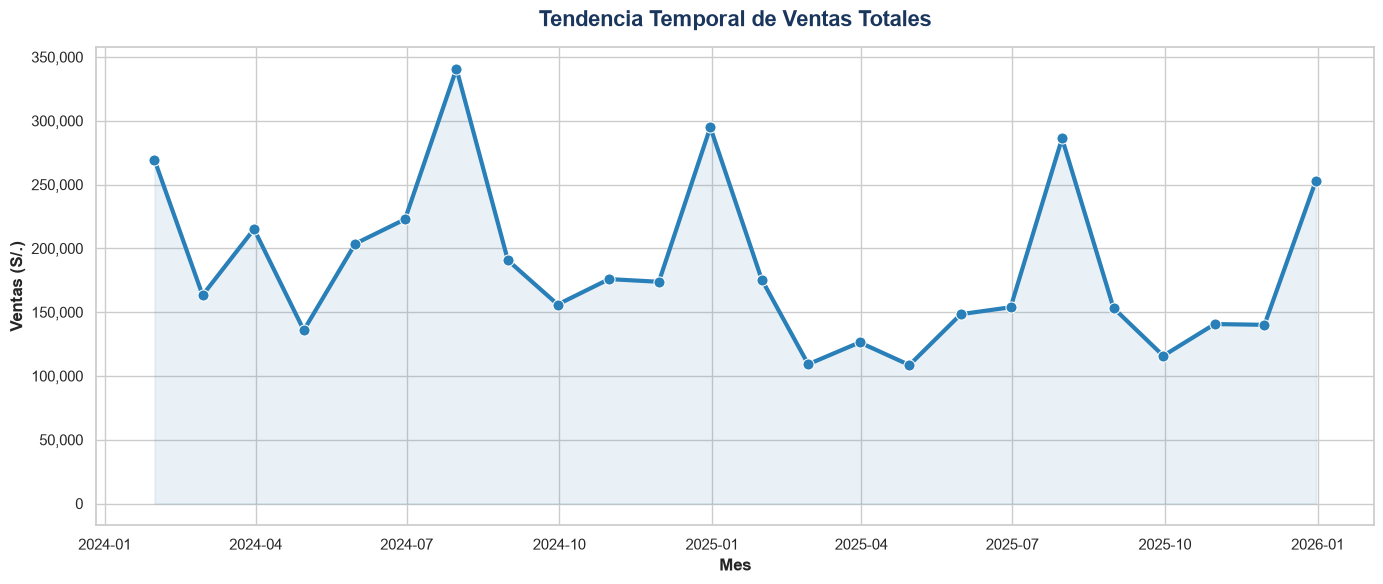

In [6]:
# 2.1 Agrupar las ventas totales (importe) por mes
# Usamos freq='ME' (Month End) para consolidar los datos mensualmente
df_mensual = df.groupby(pd.Grouper(key='fecha', freq='ME'))['importe'].sum().reset_index()

# 2.2 Configurar el estilo visual 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# 2.3 Crear el gráfico de líneas
ax = sns.lineplot(
    data=df_mensual, 
    x='fecha', 
    y='importe', 
    color='#297FB8', # Azul corporativo
    linewidth=3, 
    marker='o',
    markersize=8
)

# 2.4 Agregar un sombreado debajo de la línea 
plt.fill_between(df_mensual['fecha'], df_mensual['importe'], color='#297FB8', alpha=0.1)

# 2.5 Personalizar títulos y etiquetas
plt.title('Tendencia Temporal de Ventas Totales', fontsize=16, fontweight='bold', color='#1A365D', pad=15)
plt.xlabel('Mes', fontsize=12, fontweight='bold')
plt.ylabel('Ventas (S/.)', fontsize=12, fontweight='bold')

# Formatear el eje Y para que muestre los números con separador de miles
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 2.6 Guardar la figura en la carpeta del informe y mostrarla
plt.tight_layout()
plt.show()

### 3. Análisis de Pareto por Categorías
Aplicación del principio de Pareto (80/20) para identificar las categorías de productos que generan el mayor volumen de ingresos. Esta visualización con doble eje (ventas absolutas y porcentaje acumulado) permite priorizar los esfuerzos comerciales y la gestión de inventario en los segmentos más rentables para Botica Los Andes.

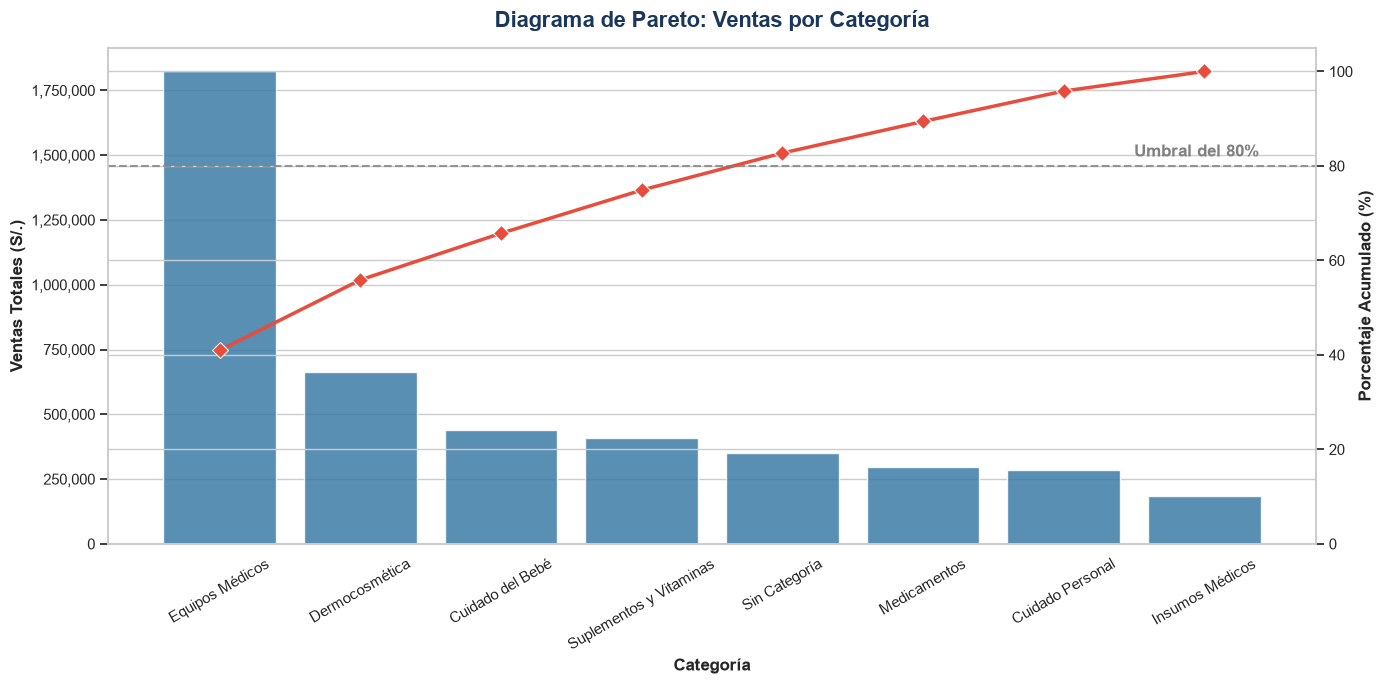

In [7]:
# 3.1 Agrupar ventas por categoría y ordenar de mayor a menor
df_pareto = df.groupby('categoria')['importe'].sum().reset_index()
df_pareto = df_pareto.sort_values(by='importe', ascending=False)

# 3.2 Calcular el porcentaje individual y luego el acumulado
df_pareto['porcentaje'] = (df_pareto['importe'] / df_pareto['importe'].sum()) * 100
df_pareto['acumulado'] = df_pareto['porcentaje'].cumsum()

# 3.3 Configurar el lienzo con doble eje Y (ax1 para S/. y ax2 para %)
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

# 3.4 Gráfico de barras (Ventas absolutas por categoría)
sns.barplot(
    data=df_pareto, 
    x='categoria', 
    y='importe', 
    ax=ax1, 
    color='#297FB8', 
    alpha=0.85
)

# 3.5 Gráfico de líneas (Porcentaje acumulado)
sns.lineplot(
    data=df_pareto, 
    x='categoria', 
    y='acumulado', 
    ax=ax2, 
    color='#E74C3C', # Un rojo suave para que resalte la línea
    marker='D', 
    linewidth=2.5,
    markersize=8
)

# 3.6 Línea de referencia del 80% (Umbral de Pareto)
ax2.axhline(80, color='gray', linestyle='dashed', linewidth=1.5, alpha=0.8)
ax2.text(len(df_pareto)-1.5, 82, 'Umbral del 80%', color='gray', fontweight='bold')

# 3.7 Formato visual y etiquetas
ax1.set_title('Diagrama de Pareto: Ventas por Categoría', fontsize=16, fontweight='bold', color='#1A365D', pad=15)
ax1.set_xlabel('Categoría', fontsize=12, fontweight='bold')
ax1.set_ylabel('Ventas Totales (S/.)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12, fontweight='bold')

# Rotar las etiquetas del eje X para evitar que los nombres se superpongan
ax1.tick_params(axis='x', rotation=30)

# Formatear el eje Y de ventas con separador de miles
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax2.set_ylim(0, 105) # Fijar el límite del porcentaje ligeramente por encima de 100

# 3.8 Exportar y mostrar
plt.tight_layout()
plt.show()

### 4. Mapa de Calor: Concentración de Ventas (Categoría vs. Mes)
Esta visualización permite identificar patrones de estacionalidad a nivel de categoría. Mediante el uso de intensidad de color, se detectan rápidamente los "picos calientes" de ventas, facilitando la programación de campañas de marketing y el abastecimiento de almacenes para los meses de mayor rotación.

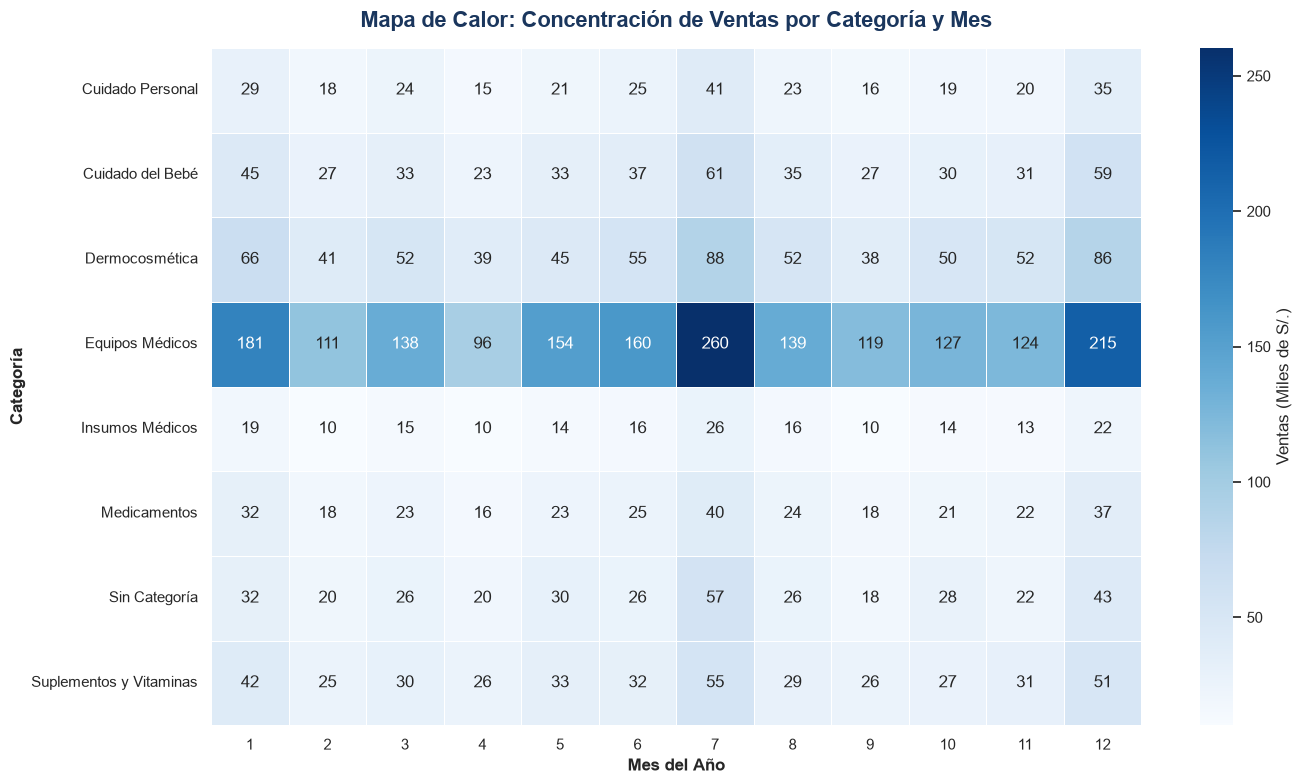

In [8]:
# 4.1 Crear una tabla pivote: Categorías vs Meses
# Dividimos el importe entre 1000 para mostrar las cifras en "Miles de S/."
df_pivot = df.pivot_table(
    values='importe', 
    index='categoria', 
    columns='mes', 
    aggfunc='sum', 
    fill_value=0
) / 1000

# 4.2 Configurar el lienzo del gráfico
plt.figure(figsize=(14, 8))

# 4.3 Crear el mapa de calor
# Utilizamos la paleta 'Blues' para mantener el color corporativo
ax = sns.heatmap(
    df_pivot, 
    cmap='Blues', 
    annot=True,         # Muestra los números dentro de los cuadros
    fmt=".0f",          # Sin decimales para mayor limpieza
    linewidths=0.5,     # Líneas separadoras entre celdas
    cbar_kws={'label': 'Ventas (Miles de S/.)'}
)

# 4.4 Personalizar títulos y etiquetas
plt.title('Mapa de Calor: Concentración de Ventas por Categoría y Mes', fontsize=16, fontweight='bold', color='#1A365D', pad=15)
plt.xlabel('Mes del Año', fontsize=12, fontweight='bold')
plt.ylabel('Categoría', fontsize=12, fontweight='bold')

# Rotar las etiquetas del eje Y para que se lean de forma horizontal
plt.yticks(rotation=0)

# 4.5 Guardar la figura en la carpeta del informe y mostrarla
plt.tight_layout()
plt.show()